In [15]:
from PIL import Image
import numpy as np
import os

# Define the colors
colors = {
    'yellow': (249, 195, 35),
    'purple': (90, 76, 164),
    'blue': (41, 167, 224)
}

# Function to compare images
def compare_images(img1, img2, colors):
    # Ensure images are the same size
    if img1.size != img2.size:
        raise ValueError("Images must have the same dimensions for comparison")
    
    # Convert images to numpy arrays
    arr1 = np.array(img1)
    arr2 = np.array(img2)
    
    # Calculate the number of matching pixels for each color
    color_matches = {color: np.sum((arr1 == rgb) & (arr2 == rgb)) for color, rgb in colors.items()}
    total_pixels = {color: np.sum(arr1==rgb) for color,rgb in colors.items()}  # Divide by 3 because each pixel has 3 values (R, G, B)

    color_matches["total"] = np.sum(arr1 == arr2)
    total_pixels["total"] = arr1.size
    
    # Calculate the percentage of matching pixels for each color
    color_percentages = {color: (matches / total_pixels[color]) * 100 for color, matches in color_matches.items()}
    
    return color_percentages

# List to store results
results = []

# Loop through the sets of images
for i in range(1, 4):
    manual_image_path = f'images/akaso{i}_manual.png'
    fuzzy_image_path = f'images/akaso{i}_fuzzy.png'
    proc_image_path = f'images/akaso{i}_proc.png'
    
    # Open images
    manual_image = Image.open(manual_image_path).convert('RGB')
    fuzzy_image = Image.open(fuzzy_image_path).convert('RGB')
    proc_image = Image.open(proc_image_path).convert('RGB')
    
    # Compare images with the manual image
    fuzzy_color_percentages = compare_images(manual_image, fuzzy_image, colors)
    proc_color_percentages = compare_images(manual_image, proc_image, colors)
    
    # Store results in the list
    results.append({
        'set': i,
        'fuzzy_color_percentages': fuzzy_color_percentages,
        'proc_color_percentages': proc_color_percentages
    })

# Print results
for result in results:
    print(f"Set {result['set']}:")
    print(f"  Fuzzy Match Percentages: {result['fuzzy_color_percentages']}")
    print(f"  Proc Match Percentages: {result['proc_color_percentages']}")
    print()


Set 1:
  Fuzzy Match Percentages: {'yellow': 11.406844106463879, 'purple': 97.15447154471545, 'blue': 74.73565205825629, 'total': 79.766845703125}
  Proc Match Percentages: {'yellow': 93.34600760456274, 'purple': 98.4446800989749, 'blue': 99.39815122697347, 'total': 98.809814453125}

Set 2:
  Fuzzy Match Percentages: {'yellow': 8.090495512111152, 'purple': 59.004269231379645, 'blue': 0.0, 'total': 25.6591796875}
  Proc Match Percentages: {'yellow': 85.94614533382516, 'purple': 98.93824691710708, 'blue': 99.46143564745657, 'total': 98.492431640625}

Set 3:
  Fuzzy Match Percentages: {'yellow': 10.33503691084611, 'purple': 62.959394847641484, 'blue': 0.0, 'total': 24.42626953125}
  Proc Match Percentages: {'yellow': 85.6473594548552, 'purple': 99.15970884178977, 'blue': 99.81863442389758, 'total': 98.89119466145834}



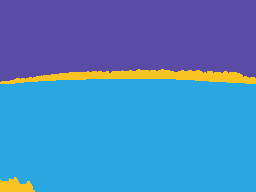

In [26]:
manual_image

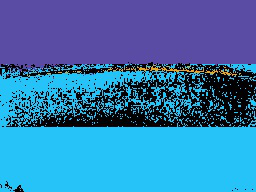

In [14]:
fuzzy_image

In [16]:
get_top_colors(fuzzy_image,num_colors=10)

[((37, 195, 247), 27496),
 ((90, 75, 164), 17727),
 ((0, 0, 0), 3589),
 ((224, 167, 41), 340)]

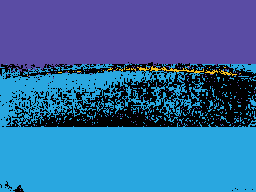

In [12]:
from PIL import Image
import numpy as np
from scipy.spatial import distance

# Definir los colores de manual_image
manual_colors = [(41, 167, 224), (90, 76, 164), (249, 195, 35),(0,0,0)]

fuzzy_image_path = f'images/akaso1_fuzzy.jpeg'
fuzzy_image = Image.open(fuzzy_image_path).convert('RGB')

# Convertir fuzzy_image a un array numpy
fuzzy_array = np.array(fuzzy_image)

# Función para encontrar el color más cercano
def find_closest_color(pixel, colors):
    closest_color = min(colors, key=lambda color: distance.euclidean(pixel, color))
    return closest_color

# Crear una nueva imagen con los colores ajustados
adjusted_array = np.zeros_like(fuzzy_array)
for i in range(fuzzy_array.shape[0]):
    for j in range(fuzzy_array.shape[1]):
        adjusted_array[i, j] = find_closest_color(fuzzy_array[i, j], manual_colors)

# Convertir el array ajustado de nuevo a una imagen
adjusted_image = Image.fromarray(adjusted_array.astype('uint8'), 'RGB')

# Guardar la nueva imagen
adjusted_image.save('images/akaso1_fuzzy.png')

# Mostrar la nueva imagen
adjusted_image

In [13]:
from collections import Counter

def get_top_colors(image, num_colors=3):
    # Convert image to numpy array
    arr = np.array(image)
    
    # Reshape array to a list of pixels
    pixels = arr.reshape(-1, arr.shape[-1])
    
    # Count the frequency of each color
    color_counts = Counter(map(tuple, pixels))
    
    # Get the most common colors
    top_colors = color_counts.most_common(num_colors)
    
    return top_colors

# Get top 3 colors for each image
manual_top_colors = get_top_colors(manual_image)
fuzzy_top_colors = get_top_colors(fuzzy_image)
proc_top_colors = get_top_colors(proc_image)

print(f"Manual Image Top Colors: {manual_top_colors}")
print(f"Fuzzy Image Top Colors: {fuzzy_top_colors}")
print(f"Proc Image Top Colors: {proc_top_colors}")

Manual Image Top Colors: [((41, 167, 224), 28120), ((90, 76, 164), 18684), ((249, 195, 35), 2348)]
Fuzzy Image Top Colors: [((90, 76, 164), 15779), ((38, 195, 248), 15398), ((8, 0, 0), 99)]
Proc Image Top Colors: [((41, 167, 224), 28353), ((90, 76, 164), 18608), ((249, 195, 35), 2191)]


In [4]:
from scipy.spatial import distance

def match_colors(manual_colors, fuzzy_colors, proc_colors):
    matched_colors = []
    
    for manual_color in manual_colors:
        manual_rgb = manual_color[0]
        
        # Find the closest fuzzy color
        closest_fuzzy_color = min(fuzzy_colors, key=lambda x: distance.euclidean(manual_rgb, x[0]))
        
        # Find the closest proc color
        closest_proc_color = min(proc_colors, key=lambda x: distance.euclidean(manual_rgb, x[0]))
        
        matched_colors.append({
            'manual_color': manual_rgb,
            'closest_fuzzy_color': closest_fuzzy_color[0],
            'closest_proc_color': closest_proc_color[0]
        })
    
    return matched_colors

# Match the top colors
matched_colors = match_colors(manual_top_colors, fuzzy_top_colors, proc_top_colors)

# Print the matched colors
for idx, colors in enumerate(matched_colors):
    print(f"Manual Color {idx+1}: {colors['manual_color']}")
    print(f"Closest Fuzzy Color: {colors['closest_fuzzy_color']}")
    print(f"Closest Proc Color: {colors['closest_proc_color']}")
    print()



Manual Color 1: (41, 167, 224)
Closest Fuzzy Color: (90, 76, 164)
Closest Proc Color: (89, 74, 175)

Manual Color 2: (90, 76, 164)
Closest Fuzzy Color: (90, 76, 164)
Closest Proc Color: (90, 76, 164)

Manual Color 3: (249, 195, 35)
Closest Fuzzy Color: (39, 195, 246)
Closest Proc Color: (41, 167, 225)

Manual Color 1: (41, 167, 224)
Closest Fuzzy Color: (90, 76, 164)
Closest Proc Color: (89, 74, 175)

Manual Color 2: (90, 76, 164)
Closest Fuzzy Color: (90, 76, 164)
Closest Proc Color: (90, 76, 164)

Manual Color 3: (249, 195, 35)
Closest Fuzzy Color: (39, 195, 246)
Closest Proc Color: (41, 167, 225)



In [5]:
import pickle
import numpy as np

In [8]:
with open("times_fuzzy.pickle", "rb") as f:
    times_wasrt = pickle.load(f)
times_wasrt

{'image_1': [0.5582103729248047,
  0.5553572177886963,
  0.5551648139953613,
  0.5522589683532715,
  0.5516853332519531,
  0.5480399131774902,
  0.5499653816223145,
  0.5489702224731445,
  0.5723302364349365,
  0.5512926578521729,
  0.5540604591369629,
  0.5497443675994873,
  0.5488004684448242,
  0.5441567897796631,
  0.5469801425933838,
  0.5478112697601318,
  0.5465071201324463,
  0.5491330623626709,
  0.5509727001190186,
  0.5660967826843262,
  0.547173261642456,
  0.5483114719390869,
  0.5504112243652344,
  0.5453805923461914,
  0.5500900745391846,
  0.5453066825866699,
  0.5695607662200928,
  0.5719208717346191,
  0.552330732345581,
  0.5477602481842041,
  0.5447111129760742,
  0.5467367172241211,
  0.5457553863525391,
  0.5469772815704346,
  0.5459573268890381,
  0.5441689491271973,
  0.546428918838501,
  0.546048641204834,
  0.5487861633300781,
  0.5483777523040771,
  0.5493645668029785,
  0.5446999073028564,
  0.5634584426879883,
  0.588083028793335,
  0.5696151256561279,
  0.

In [9]:
result = {}
final_result = []
for image, times in times_wasrt.items():
    result[image] = np.mean(times)
    final_result += times
print(result)
print(np.mean(final_result))

{'image_1': 0.5564843010902405, 'image_2': 0.6181824684143067, 'image_3': 0.6156186199188233}
0.5967617964744568
